# 多普勒效应

> 本notebook为OTFS学习教程的一部分，重点讲解多普勒效应的物理原理及其对无线通信的影响。

---
## 1. 目标

本节内容将帮助您掌握：

1. **理解多普勒效应的物理原理** - 了解相对运动如何导致接收频率的变化
2. **理解多普勒频移的计算** - 掌握多普勒频移的数学表达式及其在实际场景中的应用
3. **为理解OTFS在高移动性场景下的优势打下基础** - 认识到传统OFDM在高速移动场景面临的挑战，以及OTFS如何应对这些挑战

---
## 2. 多普勒效应直观理解

### 2.1 什么是多普勒效应？

**多普勒效应**描述的是当波源与观察者之间存在相对运动时，观察者接收到的波的频率会发生变化的现象。这一原理广泛应用于雷达、天气预报、医学超声以及无线通信等领域。

### 2.2 核心规律

| 运动方向 | 频率变化 | 直观感受 |
|:---:|:---:|:---|
| **靠近** | 频率**升高** | 警笛声变得尖锐 |
| **远离** | 频率**降低** | 警笛声变得低沉 |

### 2.3 经典类比：救护车

当救护车向你驶来时：
- 声波被压缩，波长变短
- 接收频率升高（音调尖锐）

当救护车远离你时：
- 声波被拉伸，波长变长
- 接收频率降低（音调低沉）

**关键洞察**：相对速度越大，频率偏移越明显。

---
## 3. 多普勒频移公式

### 3.1 简化公式

对于无线通信中的多普勒频移，我们使用以下简化公式：

$$f_d = \frac{v}{c} \cdot f_c$$

其中：
- $f_d$ : 多普勒频移（Hz）
- $v$ : 相对速度（m/s）
- $c$ : 光速 $\approx 3 \times 10^8$ m/s
- $f_c$ : 载波频率（Hz）

### 3.2 实际计算示例

假设场景：车辆以30 km/h的速度行驶，载波频率为4 GHz

```python
# Parameters
v = 30 * 1000 / 3600  # Convert km/h to m/s
c = 3e8               # Speed of light in m/s
f_c = 4e9             # Carrier frequency in Hz (4 GHz)

# Calculate Doppler shift
f_d = (v / c) * f_c
print(f"Doppler shift: {f_d:.2f} Hz")
```

**结果**：30 km/h @ 4 GHz → $f_d \approx 111$ Hz

### 3.3 不同速度下的多普勒频移对照表

| 场景 | 速度 (km/h) | 速度 (m/s) | 频移 (Hz) @ 4GHz |
|:---:|:---:|:---:|:---:|
| 行人 | 3 | 0.83 | 11 |
| 自行车 | 15 | 4.17 | 56 |
| 汽车 | 60 | 16.67 | 222 |
| 高铁 | 300 | 83.33 | 1111 |
| 飞机 | 900 | 250 | 3333 |

---
## 4. 代码演示：多普勒频移仿真

下面通过Python代码演示多普勒频移的计算，并可视化其对信号的影响。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Set up Chinese font support
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

### 4.1 计算不同场景下的多普勒频移

In [2]:
# Speed of light
c = 3e8  # m/s

# Carrier frequency (4 GHz - typical 5G band)
f_c = 4e9  # Hz

# Define different scenarios
scenarios = {
    'Pedestrian (3 km/h)': 3 * 1000 / 3600,
    'Car (60 km/h)': 60 * 1000 / 3600,
    'Train (300 km/h)': 300 * 1000 / 3600
}

# Calculate Doppler shift for each scenario
print("=" * 50)
print("Doppler Shift Calculation @ 4 GHz")
print("=" * 50)

doppler_shifts = {}
for name, speed in scenarios.items():
    f_d = (speed / c) * f_c
    doppler_shifts[name] = f_d
    print(f"{name}: v = {speed:.2f} m/s -> f_d = {f_d:.2f} Hz")

print("=" * 50)

Doppler Shift Calculation @ 4 GHz
Pedestrian (3 km/h): v = 0.83 m/s -> f_d = 11.11 Hz
Car (60 km/h): v = 16.67 m/s -> f_d = 222.22 Hz
Train (300 km/h): v = 83.33 m/s -> f_d = 1111.11 Hz


### 4.2 可视化多普勒频移对比

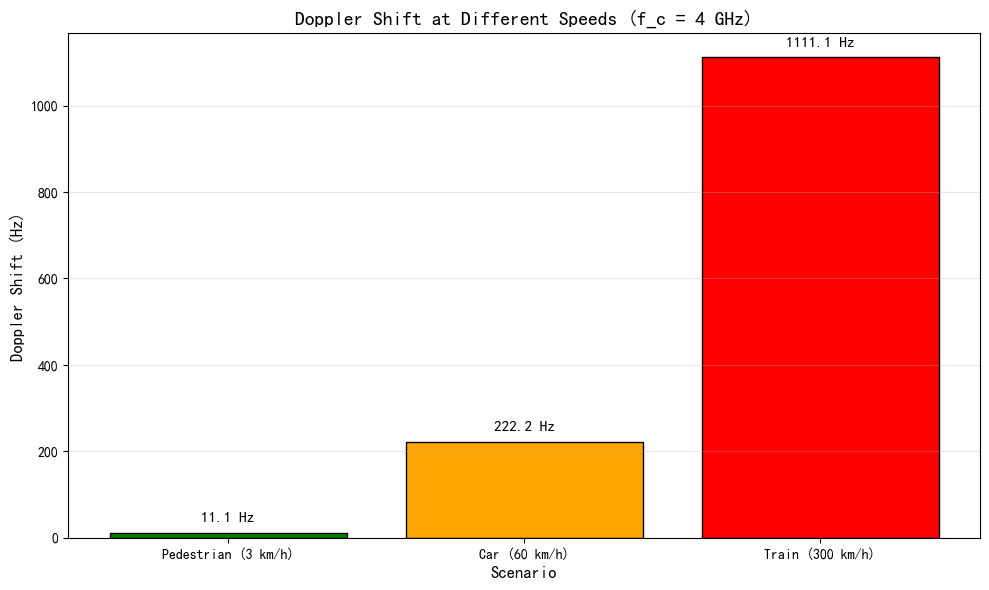

In [3]:
# Create bar chart for Doppler shifts
fig, ax = plt.subplots(figsize=(10, 6))

names = list(doppler_shifts.keys())
values = list(doppler_shifts.values())

bars = ax.bar(names, values, color=['green', 'orange', 'red'], edgecolor='black')

ax.set_ylabel('Doppler Shift (Hz)', fontsize=12)
ax.set_xlabel('Scenario', fontsize=12)
ax.set_title('Doppler Shift at Different Speeds (f_c = 4 GHz)', fontsize=14)

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:.1f} Hz', ha='center', va='bottom', fontsize=11)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 相位旋转效应仿真

多普勒频移导致接收信号的相位随时间不断旋转。下面仿真这一效应。

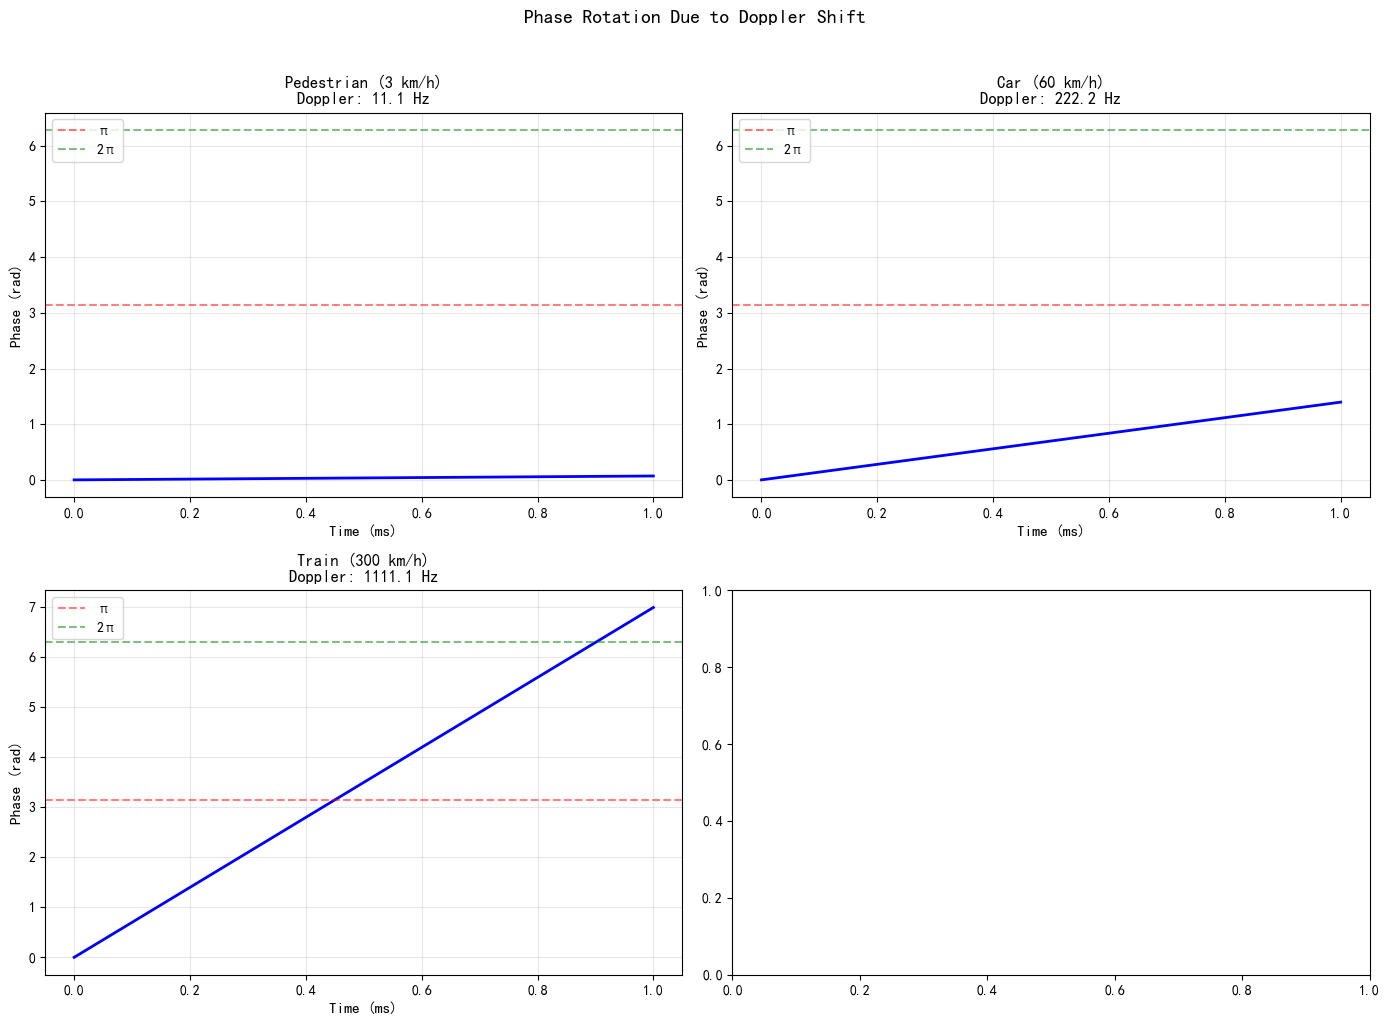

In [4]:
# Simulate phase rotation due to Doppler
# Time axis: 0 to 1 ms (1 millisecond)
t = np.linspace(0, 1e-3, 1000)  # seconds

# Original carrier frequency
f_c = 4e9  # 4 GHz

# Create figure for phase rotation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, f_d) in enumerate(doppler_shifts.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Calculate phase over time: phi(t) = 2π * f_d * t
    phase = 2 * np.pi * f_d * t
    
    # Plot phase rotation
    ax.plot(t * 1000, phase, 'b-', linewidth=2)
    ax.set_xlabel('Time (ms)', fontsize=11)
    ax.set_ylabel('Phase (rad)', fontsize=11)
    ax.set_title(f'{name}\nDoppler: {f_d:.1f} Hz', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add reference line at π and 2π
    ax.axhline(y=np.pi, color='r', linestyle='--', alpha=0.5, label='π')
    ax.axhline(y=2*np.pi, color='g', linestyle='--', alpha=0.5, label='2π')
    ax.legend(loc='upper left')

plt.suptitle('Phase Rotation Due to Doppler Shift', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 信号星座图受多普勒影响

多普勒频移会在OFDM系统中造成载波间干扰（ICI），使星座点发生旋转和扩散。

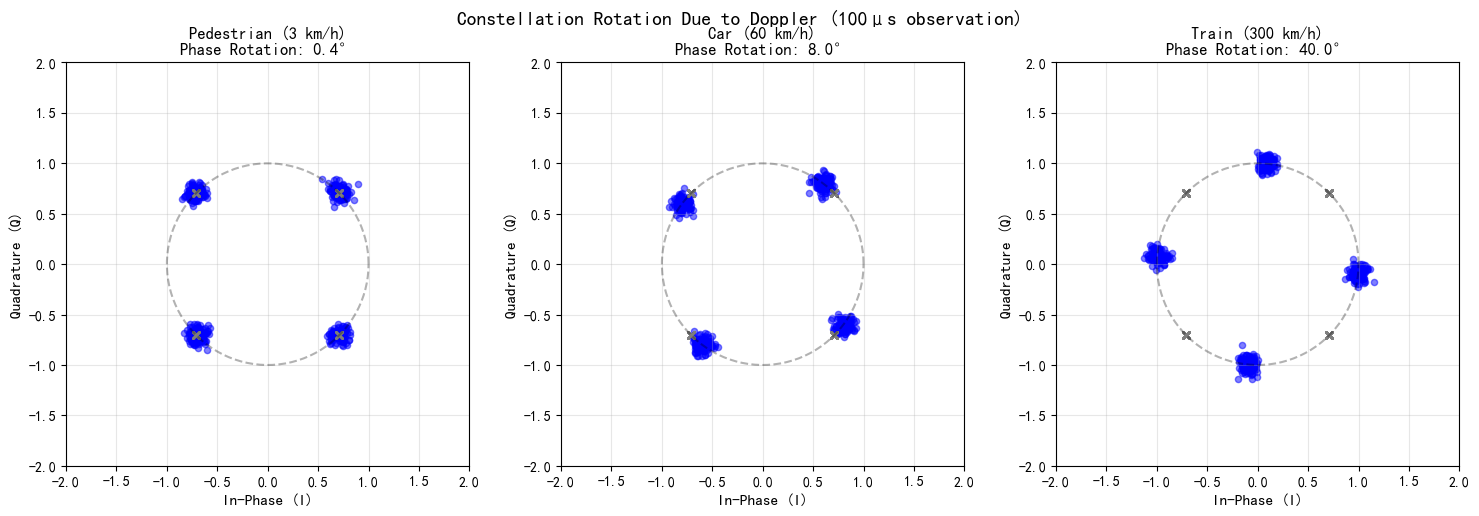

Note: Gray 'x' marks original QPSK positions, blue dots show rotated positions
Higher speed causes more phase rotation, making signal recovery harder


In [5]:
# Simulate constellation rotation due to Doppler
np.random.seed(42)

# Original QPSK symbols
n_symbols = 500
original_symbols = np.random.choice([1+1j, 1-1j, -1+1j, -1-1j], n_symbols) * 0.707

# Observation time window
t_obs = 100e-6  # 100 microseconds

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, f_d) in enumerate(doppler_shifts.items()):
    ax = axes[idx]
    
    # Calculate total phase rotation over observation time
    # This represents the differential between two subcarriers
    total_phase = 2 * np.pi * f_d * t_obs
    
    # Apply phase rotation to symbols
    rotation = np.exp(1j * total_phase)
    rotated_symbols = original_symbols * rotation
    
    # Add some spreading due to channel noise
    noise = 0.05 * (np.random.randn(n_symbols) + 1j * np.random.randn(n_symbols))
    final_symbols = rotated_symbols + noise
    
    # Plot constellation
    ax.scatter(final_symbols.real, final_symbols.imag, alpha=0.5, s=20, c='blue')
    ax.scatter(original_symbols.real, original_symbols.imag, alpha=0.3, s=30, c='gray', marker='x')
    
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.set_xlabel('In-Phase (I)', fontsize=11)
    ax.set_ylabel('Quadrature (Q)', fontsize=11)
    ax.set_title(f'{name}\nPhase Rotation: {np.degrees(total_phase):.1f}°', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Draw unit circle reference
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

plt.suptitle('Constellation Rotation Due to Doppler (100μs observation)', fontsize=14)
plt.tight_layout()
plt.show()

print("Note: Gray 'x' marks original QPSK positions, blue dots show rotated positions")
print("Higher speed causes more phase rotation, making signal recovery harder")

---
## 5. 信道的时间选择性

### 5.1 相干时间

**相干时间**（Coherence Time）$T_c$ 是信道特性保持近似不变的时间跨度。当信号持续时间小于相干时间时，信道可视为静止。

### 5.2 相干时间计算

$$T_c \approx \frac{0.423}{f_d}$$

### 5.3 相干时间与移动速度的关系

| 场景 | 多普勒频移 (Hz) | 相干时间 (ms) | 信道特性 |
|:---:|:---:|:---:|:---|
| 行人 | 11 | 38.5 | 缓慢变化 |
| 汽车 | 222 | 1.9 | 中等变化 |
| 高铁 | 1111 | 0.38 | 快速变化 |

### 5.4 关键洞察

**速度越高 → 多普勒频移越大 → 相干时间越短 → 信道变化越快**

这意味着高速移动场景下，信道估计和跟踪变得更加困难。

In [6]:
# Calculate coherence time for different scenarios
print("=" * 60)
print("Coherence Time Calculation")
print("=" * 60)
print(f"{'Scenario':<25} {'Doppler (Hz)':<15} {'Coherence Time':<15}")
print("-" * 60)

for name, f_d in doppler_shifts.items():
    T_c = 0.423 / f_d  # in seconds
    print(f"{name:<25} {f_d:<15.2f} {T_c*1000:<15.3f} ms")

print("-" * 60)
print("\nKey Insight: Higher speed -> shorter coherence time -> faster fading")

Coherence Time Calculation
Scenario                  Doppler (Hz)    Coherence Time 
------------------------------------------------------------
Pedestrian (3 km/h)       11.11           38.070          ms
Car (60 km/h)             222.22          1.903           ms
Train (300 km/h)          1111.11         0.381           ms
------------------------------------------------------------

Key Insight: Higher speed -> shorter coherence time -> faster fading


---
## 6. 关联OTFS

### 6.1 OFDM对多普勒的敏感性

传统OFDM系统在高速移动场景下面临严峻挑战：

1. **载波间干扰（ICI）**：多普勒扩展导致子载波之间产生干扰
2. **小数倍载波间隔频移**：即使很小的多普勒频移也会破坏子载波正交性
3. **信道估计困难**：短相干时间意味着信道快速变化，难以准确跟踪

### 6.2 OTFS的解决思路

OTFS（正交时频空）是一种新型调制方案，它将信号变换到时延-多普勒域：

| 特性 | OFDM | OTFS |
|:---:|:---:|:---:|
| 表示域 | 时频域 | 时延-多普勒域 |
| 多普勒处理 | 视为干扰 | 变为额外维度的多样性 |
| 信道估计 | 需要频繁更新 | 在时延-多普勒域稀疏且稳定 |
| ICI敏感性 | 高 | 低 |

### 6.3 核心优势

在时延-多普勒域中：
- **多普勒扩展**不再是有害的干扰，而是可利用的信道多样性
- **信道响应**在较长时间内保持稳定，便于估计
- **均衡**在变换域中变为简单的逐点乘积

这使得OTFS在高铁、车辆通信等高移动性场景下具有显著优势。

---
## 7. 思考题

### 7.1 基础概念

**问题1**: 如果一列火车以200 km/h的速度向你驶来，载波频率为2 GHz，多普勒频移是多少？

提示：使用公式 $f_d = (v/c) \cdot f_c$

---

**问题2**: 解释为什么救护车靠近时警笛声更高亢，远离时更低沉？

---

**问题3**: 相干时间与多普勒频移成什么关系？为什么高铁通信比低速场景更有挑战性？

---

### 7.2 进阶思考

**问题4**: 如果将载波频率从4 GHz提高到28 GHz（毫米波），对于同样的移动速度，多普勒频移会如何变化？这对系统设计有什么影响？

---

**问题5**: 在OTFS中，为什么说多普勒扩展可以被转化为"多样性"而不是干扰？请结合时延-多普勒域的特性解释。

---

### 7.3 参考答案提示

| 问题 | 答案提示 |
|:---:|:---|
| Q1 | 约200 km/h = 55.6 m/s, f_d ≈ 370 Hz |
| Q2 | 相对运动压缩/拉伸声波波长 |
| Q3 | 反比关系；短相干时间要求更频繁的信道估计 |
| Q4 | 频移增大7倍；毫米波移动性管理更具挑战 |
| Q5 | 时延-多普勒域中信道稀疏表示；每个多普勒bin可独立处理 |

---

## 小结

本notebook介绍了多普勒效应的基本概念、计算公式及其对无线通信的影响。重点理解：

1. 多普勒频移与相对速度和载波频率成正比
2. 高速移动导致短相干时间和快衰落
3. 传统OFDM对多普勒敏感，而OTFS将多普勒转化为有用多样性

下一节我们将深入探讨OTFS的原理及其如何利用时延-多普勒域处理多径和多普勒效应。